# Curating COVID example data


Canadian HV.1 and JN.1 data was downloaded on 2026-02-18 from [ViruSeq Portal](https://virusseq-dataportal.ca/explorer?filters=%7B%22content%22%3A%5B%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1696132800000%7D%2C%22op%22%3A%22%3E%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1706763599999%7D%2C%22op%22%3A%22%3C%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.lineage_analysis.lineage_name%22%2C%22value%22%3A%5B%22HV.1%22%2C%22JN.1%22%2C%22JN.1.1%22%2C%22JN.1.1.4%22%2C%22JN.1.1.7%22%2C%22JN.1.10%22%2C%22JN.1.15%22%2C%22JN.1.16%22%2C%22JN.1.18%22%2C%22JN.1.19%22%2C%22JN.1.2%22%2C%22JN.1.20%22%2C%22JN.1.22%22%2C%22JN.1.28%22%2C%22JN.1.29%22%2C%22JN.1.3%22%2C%22JN.1.30%22%2C%22JN.1.31%22%2C%22JN.1.39%22%2C%22JN.1.4%22%2C%22JN.1.4.5%22%2C%22JN.1.4.6%22%2C%22JN.1.4.7%22%2C%22JN.1.41%22%2C%22JN.1.42%22%2C%22JN.1.43%22%2C%22JN.1.43.1%22%2C%22JN.1.44%22%2C%22JN.1.45%22%2C%22JN.1.46%22%2C%22JN.1.47%22%2C%22JN.1.47.1%22%2C%22JN.1.5%22%2C%22JN.1.52%22%2C%22JN.1.55%22%2C%22JN.1.6%22%2C%22JN.1.60%22%2C%22JN.1.63%22%2C%22JN.1.7%22%2C%22JN.1.8%22%2C%22JN.1.8.1%22%2C%22JN.1.8.3%22%2C%22JN.1.9%22%5D%7D%2C%22op%22%3A%22in%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.sample_collection.sequence_submitted_by%22%2C%22value%22%3A%5B%22Public+Health+Ontario+%28PHO%29%22%5D%7D%2C%22op%22%3A%22in%22%7D%5D%2C%22op%22%3A%22and%22%7D) by selecting all data submitted between 2023-10-01 and 2024-01-31 with lineage name equal to 'HV.1', 'JN.1' or starting with 'JN.1.'.



Import necessary packages


In [1]:
import os
import pandas as pd
import Bio.SeqIO
from tqdm import tqdm
import yaml

## Double checking data contains only HV.1 and JN.1 sequences
### Metadata

In [2]:
metadata = pd.read_csv('virusseq-search-export-2026-02-18/metadata.tsv',
    parse_dates=[ 'submission date', 'sample collection date'], sep='\t')
with open('sub_variants_map.yaml', 'r') as file:
    sub_variants_map = yaml.safe_load(file)
allowed_lineages = [item for sublist in sub_variants_map.values() for item in sublist]
metadata = metadata[metadata['lineage name'].isin(allowed_lineages)]

### Sequences


In [3]:
HV_1_and_JN1_sequences = []
for record in tqdm(Bio.SeqIO.parse('virusseq-search-export-2026-02-18/sequences.fasta',
    'fasta')):
    if record.id in metadata['fasta header name'].values:
        HV_1_and_JN1_sequences.append(record)
with open('HV_1_and_JN_1_sequences_unaligned.fasta', 'w') as file:
    Bio.SeqIO.write(HV_1_and_JN1_sequences, file, 'fasta')
file.close()

5135it [00:05, 979.24it/s] 


## Explore metadata

Counts of lineages

In [4]:
metadata['lineage name'].value_counts()

lineage name
HV.1         3814
JN.1          418
JN.1.2        192
JN.1.1        178
JN.1.4        171
JN.1.31        76
JN.1.52        61
JN.1.43.1      38
JN.1.9         36
JN.1.39        24
JN.1.22        23
JN.1.4.5       20
JN.1.8         17
JN.1.47.1      13
JN.1.45        13
JN.1.19         6
JN.1.46         3
JN.1.29         3
JN.1.5          3
JN.1.3          3
JN.1.47         2
JN.1.55         2
JN.1.16         2
JN.1.6          2
JN.1.1.4        2
JN.1.10         2
JN.1.43         1
JN.1.8.3        1
JN.1.28         1
JN.1.44         1
JN.1.1.7        1
JN.1.63         1
JN.1.20         1
JN.1.41         1
JN.1.30         1
JN.1.4.7        1
JN.1.42         1
Name: count, dtype: int64

How many JN.1 & all its sublineages

In [5]:
len(metadata[metadata['lineage name']!='HV.1'])

1321

Collection date data for all HV.1.

In [6]:
metadata[metadata['lineage name']=='HV.1']['sample collection date'].describe()

count                          3814
mean     2023-11-11 09:22:33.539591
min             2023-09-10 00:00:00
25%             2023-10-27 00:00:00
50%             2023-11-13 00:00:00
75%             2023-11-28 00:00:00
max             2023-12-24 00:00:00
Name: sample collection date, dtype: object

Collection date data for all JN.1 and its sublineages.

In [7]:
metadata[metadata['lineage name']!='HV.1']['sample collection date'].describe()

count                          1321
mean     2023-12-09 01:01:02.679788
min             2023-10-15 00:00:00
25%             2023-12-04 00:00:00
50%             2023-12-12 00:00:00
75%             2023-12-18 00:00:00
max             2023-12-26 00:00:00
Name: sample collection date, dtype: object

## Aligning and masking Sequences

Sequences will be aligned using Nextclade.

### Obtaining Reference genome

In [8]:
%%bash
source activate dev_beast_pype
nextclade dataset get --name 'nextstrain/sars-cov-2/wuhan-hu-1/orfs' --output-dir 'nextclade-sars-cov-2'

### Align Sequences

In [9]:
%%bash
source activate dev_beast_pype
nextclade run \
   --input-dataset nextclade-sars-cov-2 \
   --output-all=output/ \
   HV_1_and_JN_1_sequences_unaligned.fasta

### Post-Alignment checks

#### All from the JN.1 or HV.1.

In [10]:
nextclade_df = pd.read_csv('output/nextclade.tsv', sep='\t')
nextclade_df.Nextclade_pango.value_counts()


Nextclade_pango
HV.1         3804
JN.1          429
JN.1.2        192
JN.1.4        168
JN.1.1        157
JN.1.31        76
JN.1.52        66
JN.1.43.1      38
JN.1.9         36
JN.1.39        31
JN.1.22        23
JN.1.4.5       23
JN.1.8         17
JN.1.47.1      13
HV.1.6         10
JN.1.45         8
JN.1.32         6
JN.1.19         6
JN.1.46         3
JN.1.29         3
JN.1.5          3
JN.1.47         2
JN.1.55         2
JN.1.16         2
JN.1.6          2
JN.1.1.4        2
JN.1.43         1
JN.1.8.3        1
JN.1.28         1
JN.1.44         1
JN.1.1.7        1
JN.1.63         1
JN.1.20         1
JN.1.41         1
JN.1.30.1       1
JN.1.10         1
JN.1.4.7        1
JN.1.42         1
JN.1.3          1
Name: count, dtype: int64

That is fine. 

#### Check coverage

In [11]:
nextclade_df.coverage.describe()

count    5135.000000
mean        0.989288
std         0.010284
min         0.901047
25%         0.985754
50%         0.994415
75%         0.995686
max         0.996020
Name: coverage, dtype: float64

<Axes: ylabel='Frequency'>

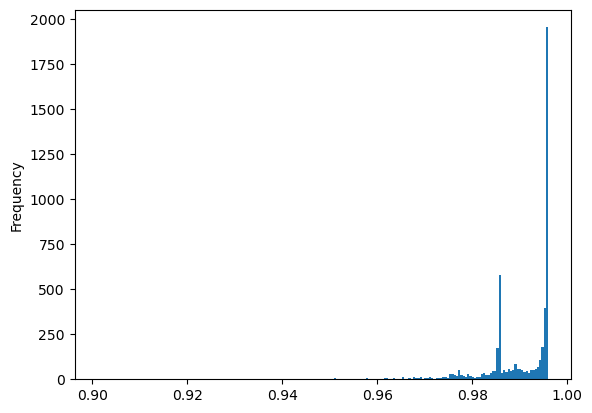

In [12]:
nextclade_df.coverage.plot.hist(bins=200)

## Increasing coverage to >= 0.98 and Saving Selection of HV.1 & JN.1 Sequences

In [13]:
sequences_ids_better_coverage = nextclade_df[nextclade_df.coverage>=0.98]['seqName'].values
metadata = metadata[metadata['fasta header name'].isin(sequences_ids_better_coverage)]
metadata.to_csv('HV_1_and_JN_1_metadata.csv', index=False)

In [14]:
selected_HV_1_and_JN1_sequences = []
for record in tqdm(Bio.SeqIO.parse('output/nextclade.aligned.fasta',
    'fasta')):
    if record.id in sequences_ids_better_coverage:
        selected_HV_1_and_JN1_sequences.append(record)
with open('HV_1_and_JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(selected_HV_1_and_JN1_sequences, file, 'fasta')
file.close()

5135it [00:07, 723.01it/s] 


## Putting JN.1 Sequences in there own dataset

In [15]:
JN1_metadata = metadata[metadata['lineage name']!='HV.1']
JN1_metadata.to_csv('JN_1_metadata.csv', index=False)


In [16]:
JN1_ids = JN1_metadata['fasta header name'].values
JN1_sequences = []

for record in tqdm(Bio.SeqIO.parse('HV_1_and_JN_1_sequences.fasta', 'fasta')):
    if record.id in JN1_ids:
        JN1_sequences.append(record)

4562it [00:04, 975.97it/s] 


In [17]:
len(JN1_sequences)

1178

In [18]:
with open('JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(JN1_sequences, file, 'fasta')
file.close()

## Putting HV.1 Sequences in there own dataset

In [19]:
HV1_metadata = metadata[metadata['lineage name']=='HV.1']
HV1_metadata.to_csv('HV_1_metadata.csv', index=False)


In [20]:
HV1_ids = HV1_metadata['fasta header name'].values
HV1_sequences = []

for record in tqdm(Bio.SeqIO.parse('HV_1_and_JN_1_sequences.fasta', 'fasta')):
    if record.id in HV1_ids:
        HV1_sequences.append(record)
with open('HV_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(HV1_sequences, file, 'fasta')
file.close()

4562it [00:01, 3139.53it/s]


### Trying to get under GitHubs file size limit (idealy 50 MiB, hard limit 100 Mib)

In [21]:
JN1_metadata['sample collection date'].describe()

count                          1178
mean     2023-12-08 11:42:53.174872
min             2023-10-15 00:00:00
25%             2023-12-03 00:00:00
50%             2023-12-12 00:00:00
75%             2023-12-18 00:00:00
max             2023-12-26 00:00:00
Name: sample collection date, dtype: object

In [22]:
HV1_metadata['sample collection date'].describe()

count                          3384
mean     2023-11-11 07:30:12.765957
min             2023-09-10 00:00:00
25%             2023-10-26 00:00:00
50%             2023-11-14 00:00:00
75%             2023-11-28 00:00:00
max             2023-12-23 00:00:00
Name: sample collection date, dtype: object

### Downsampling HV.1 sequences to 1500 sequences

In [23]:
from beast_pype.path_utils import path_to_workflow_modules
from beast_pype.nb_utils import execute_notebook
workflow_modules_path = path_to_workflow_modules()

In [24]:
iq_tree_params = {
    'save_dir': os.getcwd(),
    'fasta_path': 'HV_1_sequences.fasta',
    'max_threads':3,
    'tree_dir_name':'HV_1_iqtree',
    'kernel_name':'dev_beast_pype',
    'seed':42
}

execute_notebook(f'{workflow_modules_path}/Phase-2i-and-2iii-IQTree-Building.ipynb',
                 'HV1_IQ_tree_building.ipynb', 
                 parameters=iq_tree_params,
                 progress_bar=True,
                 nest_asyncio=True)
execute_notebook(f'{workflow_modules_path}/Phase-2i-and-2iii-IQTree-Correction.ipynb', 'HV1_IQ_tree_correction.ipynb', 
                 parameters=iq_tree_params,
                 progress_bar=True,
                 nest_asyncio=True, 
                 kernel_name='dev_beast_pype')

Translator for 'bash' language does not support parameter introspection.
Passed unknown parameter: save_dir
Passed unknown parameter: fasta_path
Passed unknown parameter: max_threads
Passed unknown parameter: tree_dir_name
Passed unknown parameter: kernel_name
Passed unknown parameter: seed


Executing:   0%|          | 0/7 [00:00<?, ?cell/s]

Passed unknown parameter: max_threads
Passed unknown parameter: kernel_name
Passed unknown parameter: seed


Executing:   0%|          | 0/5 [00:00<?, ?cell/s]

In [25]:
tree_time_and_downsampling_params = {
    'save_dir': os.getcwd(),
    'fasta_path': 'HV_1_sequences.fasta',
    'metadata_path': 'HV_1_metadata.csv',
     'sample_id_field':'fasta header name',
     'collection_date_field':'sample collection date',
    'tree_dir_name':'HV_1_iqtree',
    'seed':42,
    'downsample_to':1500
}
execute_notebook(f'{workflow_modules_path}/Phase-2ii-and-2iv-TreeTime-and-Downsampling.ipynb',
                 'HV1_tree_time_and_downsampling.ipynb',
                 parameters=tree_time_and_downsampling_params ,
                 progress_bar=True,
                 nest_asyncio=True, 
                 kernel_name='dev_beast_pype')

Executing:   0%|          | 0/16 [00:00<?, ?cell/s]

Renaming downsampled files.

In [26]:
os.rename('downsampled_metadata.csv', 'downsampled_HV_1_metadata.csv')
os.rename('downsampled_sequences.fasta', 'downsampled_HV_1_sequences.fasta')

### Merging downsampled HV.1 sequences with JN.1 sequences and saving final datasets
#### Metadata

In [27]:
downsampled_HV1_metadata = pd.read_csv('downsampled_HV_1_metadata.csv',parse_dates=[ 'submission date', 'sample collection date'])
test_metadata = pd.concat([downsampled_HV1_metadata, JN1_metadata])
test_metadata.to_csv('test_HV_1_and_JN_1_metadata.csv', index=False)

In [28]:
from itertools import chain
JN1_sequences = list(Bio.SeqIO.parse('JN_1_sequences.fasta', 'fasta'))
downsampled_HV1_sequences = list(Bio.SeqIO.parse('downsampled_HV_1_sequences.fasta', 'fasta'))

test_sequences = chain(JN1_sequences, downsampled_HV1_sequences)
with open('test_HV_1_and_JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(test_sequences, file, 'fasta')

In [29]:
downsampled_HV1_metadata['sample collection date'].describe()


count                          1500
mean     2023-11-10 12:41:16.800000
min             2023-09-11 00:00:00
25%             2023-10-25 00:00:00
50%             2023-11-13 00:00:00
75%             2023-11-28 00:00:00
max             2023-12-23 00:00:00
Name: sample collection date, dtype: object

In [34]:
import yaml
my_list = JN1_metadata['lineage name'].unique().tolist()

yml_list = yaml.dump(my_list, default_flow_style=False)
with open("JN_1_lineages.yml", "w") as f:
    f.write(yml_list)

In [32]:
yml_list

'- JN.1.31\n- JN.1.4\n- JN.1\n- JN.1.46\n- JN.1.2\n- JN.1.9\n- JN.1.22\n- JN.1.43\n- JN.1.45\n- JN.1.47\n- JN.1.29\n- JN.1.52\n- JN.1.1\n- JN.1.4.5\n- JN.1.47.1\n- JN.1.8\n- JN.1.43.1\n- JN.1.39\n- JN.1.55\n- JN.1.19\n- JN.1.16\n- JN.1.28\n- JN.1.6\n- JN.1.44\n- JN.1.1.7\n- JN.1.1.4\n- JN.1.63\n- JN.1.20\n- JN.1.41\n- JN.1.30\n- JN.1.5\n- JN.1.10\n- JN.1.4.7\n- JN.1.42\n- JN.1.3\n'